# Notebook 03 — Kalman Filter: Dynamic Team Strength
### xG Spread Mean-Reversion Model · Premier League 2015–2025

# ─────────────────────────────────────────────────────────────────
# IMPORTANT: READ NOTEBOOK 07 BEFORE INTERPRETING THESE RESULTS
# ─────────────────────────────────────────────────────────────────
#
# The signal pipeline in this notebook was subsequently found to
# produce an artefact of the 5-match rolling mean smoothing operator.
# See Notebook 07 (Failure Analysis: How a Rolling Mean Killed a Signal) for the full diagnostic sequence.
#
# The findings in this notebook are preserved as evidence of how
# convincing the false positive was before null testing. They should
# not be interpreted as evidence of genuine mean reversion.
# ─────────────────────────────────────────────────────────────────

---

## Purpose

This notebook estimates latent team strength using a 1D Kalman filter.
The goal is not to smooth the xG spread — that would destroy the mean‑reversion signal — but to estimate the underlying team quality that influences match outcomes.

The Kalman filter provides:

- a causal, walk‑forward estimate of team strength

- uncertainty (variance) around each estimate

- season‑level rankings used for mechanism decomposition and opponent‑quality conditioning

The output feeds into the trading simulation (Notebook 05B) and the mechanism analysis (Notebook 06).

The notebook tracks each team's underlying attacking strength as a **latent (unobservable) state variable** that evolves continuously across matches. The Kalman filter combines noisy match-level xG observations with a model of how team strength changes over time, producing a posterior estimate of current strength.  And critically, a **confidence interval** around that estimate.

---

## Why Not Just Use Raw xG?

A single match xG is highly noisy — a team can generate 3.5 xG and score 0 goals, or create 0.8 xG and score 2. The season average is cleaner but treats all matches equally and ignores the possibility that team strength drifts across the season (due to injuries, managerial changes, form runs).

The Kalman filter solves both problems simultaneously:
- **Noise reduction:** Down-weights individual noisy observations relative to the running estimate
- **Drift tracking:** Allows the strength estimate to evolve across seasons as squads and tactics change
- **Uncertainty quantification:** Produces a variance estimate at every match — wider bounds indicate periods of high uncertainty (useful for position sizing in the trading simulation)

---

## State Space Formulation

We use a 1-dimensional random walk state space model:

**State transition (how strength changes between matches):**
$$\alpha_{t+1} = \alpha_t + w_t \quad w_t \sim \mathcal{N}(0, Q)$$

**Observation equation (how we observe strength through xG):**
$$y_t = \alpha_t + v_t \quad v_t \sim \mathcal{N}(0, R)$$

| Symbol | Meaning | Estimated from |
|---|---|---|
| $\alpha_t$ | Latent team strength at match $t$ | Inferred by filter |
| $Q$ | Process noise — how much strength drifts per match | Season-to-season xG variance |
| $R$ | Measurement noise — how noisy is one match's xG | Within-season xG variance |

**The key ratio $Q/R$:** If $Q \ll R$, the filter trusts history over new observations (strength is stable). If $Q \approx R$, the filter updates aggressively (strength changes quickly). We estimate both from data rather than setting them by hand.

**Energy market parallel:** The Kalman filter is used in energy trading to estimate unobservable demand states from noisy meter readings, or to track latent fuel cost curves from observed power prices. The mathematical structure is identical.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Imports and load data
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
# Suppress only hmmlearn convergence warnings — not all warnings.
# Remove this line to see full deprecation warnings during development.
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='hmmlearn')
warnings.filterwarnings('ignore', message='.*convergence.*')

from pathlib import Path
             
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / "data"

# team_match     = pd.read_csv(f"{PROJECT_DIR}pl_team_match_spread.csv",
#                               parse_dates=['date'])
# eligible       = pd.read_csv(f"{PROJECT_DIR}eligible_teams.csv")

team_match = pd.read_csv(
    DATA_DIR / "pl_team_match_spread.csv",
    parse_dates=['date']
)
eligible = pd.read_csv(DATA_DIR / "eligible_teams.csv")


eligible_teams = eligible['team'].tolist()

print(f"Loaded team_match: {team_match.shape}")
print(f"Eligible teams: {len(eligible_teams)}")

Loaded team_match: (7600, 11)
Eligible teams: 20


---
## Estimating Q and R from Data

Both noise parameters are estimated from the observed xG data rather than set by hand:

- **R (measurement noise)** = average within-season variance of match xG. Computed as the mean of the per-season xG variance for each team.
- **Q (process noise)** = variance of season-mean xG across years. This captures how much the team's average attacking strength changes from season to season.

**Floor for Q:** We set a minimum Q of 0.01 to prevent filter degeneracy in teams with very few season transitions (e.g. Brentford and Fulham, both promoted to the Premier League recently). Without the floor, Q could be estimated as effectively zero, making the filter ignore all new information.

**Q < R for all teams** is the expected and correct result. It means measurement noise (within a season) exceeds process noise (between seasons) — so the filter correctly leans on the historical estimate rather than chasing each individual match.

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Estimate Q and R for each team
# ─────────────────────────────────────────────────────────────────
#
# Q: process noise = season-to-season variance in mean xG
#    Measures how much team strength drifts between seasons.
#    High Q → filter reacts quickly to new data.
#
# R: measurement noise = average within-season variance in match xG
#    Measures how noisy individual match observations are.
#    High R → filter trusts history more than single matches.
#
# Q/R ratio: signal-to-noise. Should be <1 for all teams.

noise_params = {}

for team in eligible_teams:
    data = team_match[team_match['team'] == team].sort_values('date')

    # R: mean within-season xG variance
    R = data.groupby('season')['xg'].var().mean()

    # Q: variance of season-mean xG (between-season drift)
    season_means = data.groupby('season')['xg'].mean()
    Q = season_means.var() if len(season_means) > 1 else 0.01

    # Floor Q to prevent degeneracy for teams with few season transitions
    Q = max(Q, 0.01)

    noise_params[team] = {'Q': round(Q, 6), 'R': round(R, 6)}

noise_df = pd.DataFrame(noise_params).T.reset_index()
noise_df.columns = ['team', 'Q', 'R']
noise_df['Q_over_R'] = (noise_df['Q'] / noise_df['R']).round(4)

print("── Q/R ratios (signal-to-noise) — should all be < 1 ─────────")
print("  High Q/R → filter reacts quickly to new data")
print("  Low Q/R  → filter trusts historical estimate more")
print()
print(noise_df.sort_values('Q_over_R', ascending=False).to_string(index=False))

# Verify Q < R for all teams (filter correctly specified)
all_correct = (noise_df['Q'] < noise_df['R']).all()
print(f"\n  Q < R for all teams: {'✓' if all_correct else '✗'}")

── Q/R ratios (signal-to-noise) — should all be < 1 ─────────
  High Q/R → filter reacts quickly to new data
  Low Q/R  → filter trusts historical estimate more

                   team        Q        R  Q_over_R
       Newcastle United 0.248588 0.825620    0.3011
            Aston Villa 0.142597 0.606768    0.2350
               Brighton 0.136996 0.602951    0.2272
            Bournemouth 0.111165 0.546416    0.2034
         Crystal Palace 0.072680 0.579002    0.1255
              Liverpool 0.113406 0.940451    0.1206
Wolverhampton Wanderers 0.041046 0.416991    0.0984
                Arsenal 0.077938 0.890164    0.0876
              Leicester 0.057742 0.696254    0.0829
        Manchester City 0.082988 1.010885    0.0821
                Chelsea 0.061162 0.771690    0.0793
                 Fulham 0.034474 0.529295    0.0651
            Southampton 0.030271 0.505992    0.0598
                Burnley 0.022431 0.434563    0.0516
      Manchester United 0.038231 0.749615    0.0510
      

---
## The Kalman Filter Algorithm

The Kalman filter runs two steps at every match:

**Predict step:** The current strength estimate is propagated forward. Without new information, the variance grows by Q (uncertainty increases with time).

$$\hat{\alpha}_{t|t-1} = \hat{\alpha}_{t-1|t-1}$$
$$P_{t|t-1} = P_{t-1|t-1} + Q$$

**Update step:** The new match's xG observation is incorporated. The **Kalman gain K** determines how much weight to give the new observation vs the prediction:

$$K_t = \frac{P_{t|t-1}}{P_{t|t-1} + R}$$
$$\hat{\alpha}_{t|t} = \hat{\alpha}_{t|t-1} + K_t(y_t - \hat{\alpha}_{t|t-1})$$
$$P_{t|t} = (1 - K_t) P_{t|t-1}$$

When R is large (noisy observations), K is small — the filter barely moves. When R is small (precise observations), K approaches 1 — the filter fully trusts the new observation. In our case, R >> Q so K is always small and the filter moves slowly.

In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Kalman filter implementation
# ─────────────────────────────────────────────────────────────────
#
# 1D Kalman filter for latent state tracking.
# Iterates predict → update across all matches in chronological order.
#
# Initialisation:
#   Prior mean = first match xG (best available estimate before any history)
#   Prior variance = R (we're as uncertain as one match's noise level)

def kalman_filter(observations, Q, R):
    """
    1D Kalman filter for tracking a latent state.

    Parameters
    ----------
    observations : array-like  — match-level xG values in time order
    Q : float  — process noise variance (between-match drift)
    R : float  — measurement noise variance (within-match xG noise)

    Returns
    -------
    filtered_means : array of posterior mean estimates (strength)
    filtered_vars  : array of posterior variance estimates (uncertainty)
    """
    n         = len(observations)
    means     = np.zeros(n)
    variances = np.zeros(n)

    # Initialise: prior = first observation, uncertainty = R
    means[0]     = observations[0]
    variances[0] = R

    for t in range(1, n):
        # ── Predict step ───────────────────────────────────────────
        # Propagate estimate forward; uncertainty grows by Q
        predicted_mean = means[t-1]            # no drift in random walk
        predicted_var  = variances[t-1] + Q    # uncertainty increases

        # ── Update step ────────────────────────────────────────────
        # Kalman gain: fraction of the prediction error to incorporate
        # K close to 0 → trust prediction; K close to 1 → trust observation
        K = predicted_var / (predicted_var + R)

        # Update mean: prediction + K × (observation − prediction)
        means[t]     = predicted_mean + K * (observations[t] - predicted_mean)
        # Update variance: reduced by the Kalman gain
        variances[t] = (1 - K) * predicted_var

    return means, variances

print("kalman_filter() defined — ready to run across all eligible teams")

kalman_filter() defined — ready to run across all eligible teams


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Apply Kalman filter to all eligible teams
# ─────────────────────────────────────────────────────────────────
#
# For each team, run the Kalman filter on the full chronological
# sequence of match xG values (all seasons concatenated).
#
# Output columns added:
#   kalman_strength : posterior mean estimate of team strength
#   kalman_variance : posterior variance (uncertainty)
#   kalman_upper    : 95% confidence upper bound
#   kalman_lower    : 95% confidence lower bound
#
# Output: pl_kalman_strength.csv

all_kalman = []

for team in eligible_teams:
    team_data = (
        team_match[team_match['team'] == team]
        .sort_values('date')
        .copy()
    )

    obs = team_data['xg'].values
    Q   = noise_params[team]['Q']
    R   = noise_params[team]['R']

    means, variances = kalman_filter(obs, Q, R)

    team_data['kalman_strength'] = means
    team_data['kalman_variance'] = variances
    # 1.96 standard deviations = 95% confidence interval
    team_data['kalman_upper']    = means + 1.96 * np.sqrt(variances)
    team_data['kalman_lower']    = means - 1.96 * np.sqrt(variances)

    all_kalman.append(team_data)

kalman_df = pd.concat(all_kalman, ignore_index=True)
kalman_df.to_csv(f"{PROJECT_DIR}pl_kalman_strength.csv", index=False)

print(f"Saved pl_kalman_strength.csv — shape: {kalman_df.shape}")

# Spot check: Man City average Kalman strength across seasons
print("\n── Man City Kalman strength by season (end-of-season) ───────")
city = kalman_df[kalman_df['team'] == 'Manchester City'].sort_values('date')
city_end = city.groupby('season')['kalman_strength'].last().round(3)
print(city_end.to_string())

Saved pl_kalman_strength.csv — shape: (6422, 15)

── Man City Kalman strength by season (end-of-season) ───────
season
2015    1.512
2016    2.598
2017    1.742
2018    2.007
2019    3.125
2020    1.964
2021    2.923
2022    1.748
2023    2.711
2024    1.851


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — End-of-season strength rankings
# ─────────────────────────────────────────────────────────────────
#
# The Kalman estimate at the FINAL match of each season incorporates
# all 38 matches of evidence. This gives a more stable and informative
# strength ranking than raw season-average xG.
#
# We save the end-of-season estimates and show rankings for four
# seasons of particular interest.
#
# Output: kalman_end_season.csv

end_season = (
    kalman_df.sort_values('date')
    .groupby(['team','season'])
    .last()
    .reset_index()
    [['team','season','kalman_strength','kalman_variance',
      'kalman_upper','kalman_lower']]
)

end_season.to_csv(f"{PROJECT_DIR}kalman_end_season.csv", index=False)

# Show rankings for four seasons of interest
for season, note in [
    (2015, 'Leicester title year — does the model rank them #1?'),
    (2019, 'Liverpool 18pt win — did Man City dominate xG?'),
    (2022, 'Ten Hag year 1 at Man United'),
    (2024, 'Man City decline — how far have they dropped?'),
]:
    season_df = (
        end_season[end_season['season'] == season]
        .sort_values('kalman_strength', ascending=False)
        .head(6)
    )
    if season_df.empty:
        continue
    print(f"\n── {season}–{season-1999} | {note}")
    for rank, (_, row) in enumerate(season_df.iterrows(), 1):
        print(f"  {rank}. {row['team']:<25} strength: {row['kalman_strength']:.3f}")


── 2015–16 | Leicester title year — does the model rank them #1?
  1. Leicester                 strength: 2.242
  2. West Ham                  strength: 2.100
  3. Southampton               strength: 1.968
  4. Arsenal                   strength: 1.806
  5. Tottenham                 strength: 1.784
  6. Manchester City           strength: 1.512

── 2019–20 | Liverpool 18pt win — did Man City dominate xG?
  1. Manchester City           strength: 3.125
  2. Chelsea                   strength: 2.046
  3. Southampton               strength: 1.748
  4. Manchester United         strength: 1.698
  5. Watford                   strength: 1.587
  6. West Ham                  strength: 1.498

── 2022–23 | Ten Hag year 1 at Man United
  1. Manchester United         strength: 2.593
  2. Liverpool                 strength: 2.374
  3. Newcastle United          strength: 2.186
  4. Aston Villa               strength: 1.865
  5. Arsenal                   strength: 1.777
  6. Brighton                  

In [6]:
# ─────────────────────────────────────────────────────────────────
# FIG SETUP — palette, rcParams, shared data
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# End-of-season Kalman strength table (computed in Cell 5)
end_season = (
    kalman_df.sort_values('date')
    .groupby(['team', 'season'])
    .last()
    .reset_index()
    [['team', 'season', 'kalman_strength', 'kalman_variance',
      'kalman_upper', 'kalman_lower']]
)

print("Figure setup complete — FIG_DIR:", FIG_DIR.resolve())

Figure setup complete — FIG_DIR: /home/ndrew/xG-spread-model/figures


### Filter Reactivity: Q/R Ratio by Team

The Q/R ratio is the single most important hyperparameter of the Kalman filter: it determines how quickly the filter forgets the past and reacts to new observations. A high ratio means the filter treats team strength as volatile and updates aggressively after each match. A low ratio means the filter trusts accumulated history and barely moves.
All 20 teams have Q/R < 1, confirming the filter is correctly specified — within-season match noise always exceeds season-to-season drift. But the spread across teams is substantial, from Everton at 0.031 (essentially ignoring individual matches) to Newcastle United at 0.301 (reacting almost three times as quickly). Newcastle's high reactivity reflects the dramatic squad transformation that followed the 2021 takeover — the model correctly treats their strength as fast-moving.
The colour split at the median (≈ 0.075) cleanly separates the historically stable "big six" clubs from the more volatile promoted and mid-table sides, with Bournemouth and Brighton joining Newcastle as the three most reactive filters.

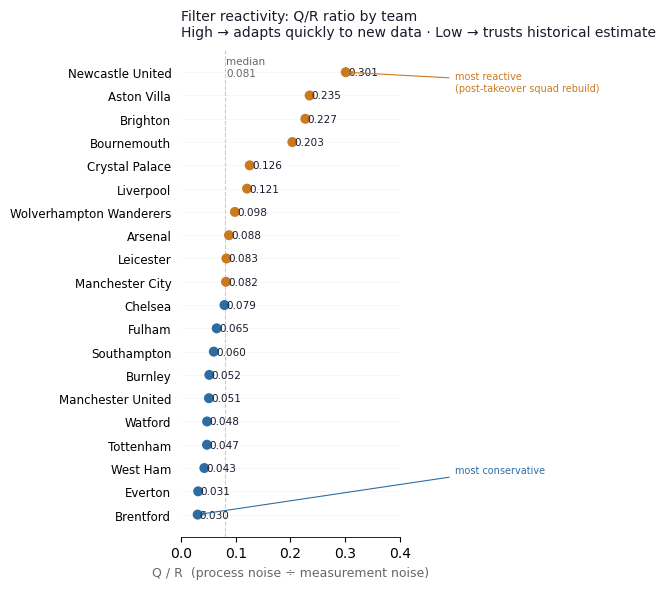

In [13]:
# ─────────────────────────────────────────────────────────────────
# FIG 1 — Q/R ratio Cleveland dot plot
# ─────────────────────────────────────────────────────────────────

sorted_df = noise_df.sort_values('Q_over_R', ascending=True).reset_index(drop=True)
y = np.arange(len(sorted_df))
med = sorted_df['Q_over_R'].median()

fig, ax = plt.subplots(figsize=(7, 6))

# Faint horizontal guide rules
for yi in y:
    ax.axhline(yi, color='#F5F5F5', lw=0.5, zorder=0)

# Median reference line
ax.axvline(med, color=LGREY, lw=0.8, ls='--', zorder=1)
ax.text(med + 0.002, len(sorted_df) - 0.3,
        f'median\n{med:.3f}', fontsize=7.5, color=GREY, va='top')

# Dots — amber above median, blue below
colours = [BLUE if v < med else AMBER for v in sorted_df['Q_over_R']]
ax.scatter(sorted_df['Q_over_R'], y, color=colours, s=52, zorder=3, linewidths=0)

# Direct value labels
for val, yi in zip(sorted_df['Q_over_R'], y):
    ax.text(val + 0.004, yi, f'{val:.3f}', va='center', fontsize=7.5, color=DARK)

ax.set_yticks(y)
ax.set_yticklabels(sorted_df['team'], fontsize=8.5)
ax.set_xlabel('Q / R  (process noise ÷ measurement noise)', fontsize=9, color=GREY)
ax.set_xlim(0, 0.40)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

# Annotations for extremes
ax.annotate('most reactive\n(post-takeover squad rebuild)',
            xy=(sorted_df.iloc[-1]['Q_over_R'], len(sorted_df) - 1),
            xytext=(0.5, len(sorted_df) - 1.8),
            fontsize=7, color=AMBER,
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=0.8))
ax.annotate('most conservative',
            xy=(sorted_df.iloc[0]['Q_over_R'], 0),
            xytext=(0.5, 1.8),
            fontsize=7, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.8))

ax.set_title('Filter reactivity: Q/R ratio by team\n'
             'High → adapts quickly to new data · Low → trusts historical estimate',
             fontsize=10, color=DARK, pad=10, loc='left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_fig1_qr_ratio_dotplot.png')
plt.show()

### Kalman Strength Trajectories: Four Teams

The filter's output is best understood through its time-series: a smoothed latent strength estimate bracketed by a 95% confidence interval, evolving match by match across the decade. Four teams are shown here as small multiples on a shared y-axis, chosen because each tells a structurally different story.
Manchester City display the widest amplitude — from a modest 1.5 in their transitional 2015–16 season to a peak of 3.1 in 2019–20 under Guardiola's most dominant iteration, before a clear downward drift through 2024. The confidence bands narrow steadily across the first season of each club's data as the filter accumulates evidence, widening again briefly after managerial changes and summer squads.
Liverpool track closely behind City for most of the decade, with the two clubs trading supremacy. Their confidence bands are notably tighter — a direct consequence of Liverpool's lower Q/R ratio (0.12 vs City's 0.08), meaning the filter converges quickly and is rarely surprised.
Arsenal provide the decade's most interesting arc: a long period of mediocre xG output (2016–20) that the filter traces faithfully as gradual decline, followed by a sharp post-Arteta recovery that the model captures in its CI bands narrowing and rising simultaneously — a signal that the filter is not just tracking a noisy mean but detecting genuine structural improvement.
Newcastle United show the most dramatic single inflection point: the 2021 takeover and associated squad investment appears in the filter as a sustained upward shift that persists across subsequent seasons, distinguishing real structural change from noise.

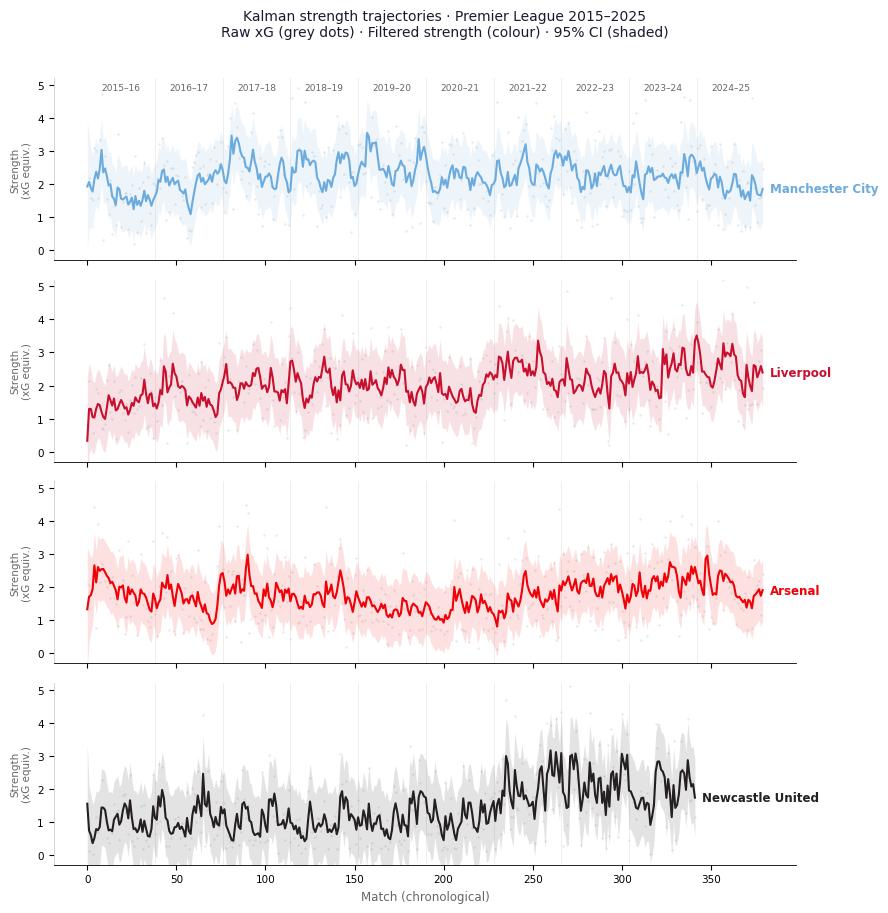

In [8]:
# ─────────────────────────────────────────────────────────────────
# FIG 2 — Kalman strength trajectories: 4 teams, small multiples
# ─────────────────────────────────────────────────────────────────

focus_teams = ['Manchester City', 'Liverpool', 'Arsenal', 'Newcastle United']
team_colours = {
    'Manchester City':  '#6CABDD',
    'Liverpool':        '#C8102E',
    'Arsenal':          '#EF0107',
    'Newcastle United': '#241F20',
}

seasons_list = sorted(kalman_df['season'].unique())
season_starts = {s: i * 38 for i, s in enumerate(seasons_list)}

# Build a continuous match index per team so CI bands connect cleanly
def build_team_series(team):
    df = (
        kalman_df[kalman_df['team'] == team]
        .sort_values('date')
        .reset_index(drop=True)
    )
    df['match_idx'] = np.arange(len(df))
    return df

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True, sharey=True)
fig.suptitle(
    'Kalman strength trajectories · Premier League 2015–2025\n'
    'Raw xG (grey dots) · Filtered strength (colour) · 95% CI (shaded)',
    fontsize=10, color=DARK, y=1.01
)

for ax, team in zip(axes, focus_teams):
    df  = build_team_series(team)
    col = team_colours[team]
    n   = len(df)

    # Season dividers
    for i in range(1, len(seasons_list)):
        x_div = i * 38
        if x_div < n:
            ax.axvline(x_div, color='#EBEBEB', lw=0.6, zorder=0)

    # Season labels along top of first panel only
    if team == focus_teams[0]:
        for i, s in enumerate(seasons_list):
            ax.text(i * 38 + 19, 4.85,
                    f"{s}–{str(s+1)[-2:]}",
                    ha='center', fontsize=6.5, color=GREY)

    # Raw xG scatter
    ax.scatter(df['match_idx'], df['xg'],
               s=3, color=LGREY, alpha=0.45, linewidths=0, zorder=1)

    # 95% CI band
    ax.fill_between(df['match_idx'],
                    df['kalman_lower'], df['kalman_upper'],
                    color=col, alpha=0.12, linewidth=0, zorder=2)

    # Kalman mean line
    ax.plot(df['match_idx'], df['kalman_strength'],
            color=col, lw=1.5, zorder=3)

    # Direct team label at right margin
    last = df.iloc[-1]
    ax.text(n + 3, last['kalman_strength'], team,
            va='center', fontsize=8.5, color=col, fontweight='bold')

    ax.set_ylabel('Strength\n(xG equiv.)', fontsize=7.5, color=GREY)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_ylim(-0.3, 5.2)
    ax.spines['left'].set_color(LGREY)
    ax.tick_params(axis='y', labelsize=7.5)

axes[-1].set_xlabel('Match (chronological)', fontsize=8.5, color=GREY)
axes[-1].tick_params(axis='x', labelsize=7.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_fig2_kalman_trajectories.png')
plt.show()

### End-of-Season Strength Heatmap

The heatmap provides the full picture: all 20 eligible teams across all 10 seasons, sorted by career mean Kalman strength. Each cell value is the posterior mean at the final match of that season — a stable, noise-filtered estimate that incorporates 38 matches of evidence. Unlike raw season-average xG, it respects the temporal structure of the data.
Several patterns stand out immediately. Manchester City's dominance is unmistakeable — consistently the darkest cells in the top half of the chart, peaking at 3.12 in 2019–20. Liverpool sit just below them for most of the decade before surging to the top in 2024. The arrival of the Brighton model as a top-five side by strength — despite a fraction of City's transfer budget — is one of the chart's most striking findings.
At the bottom, Burnley, Watford, and West Brom appear as consistently pale rows: low absolute strength and few seasons of PL data, which means the filter spent much of their time building confidence rather than converging. These are the teams where the 95% CI bands (visible in Fig 2) are widest. The heatmap makes this evident through the combination of low values and patchy coverage.

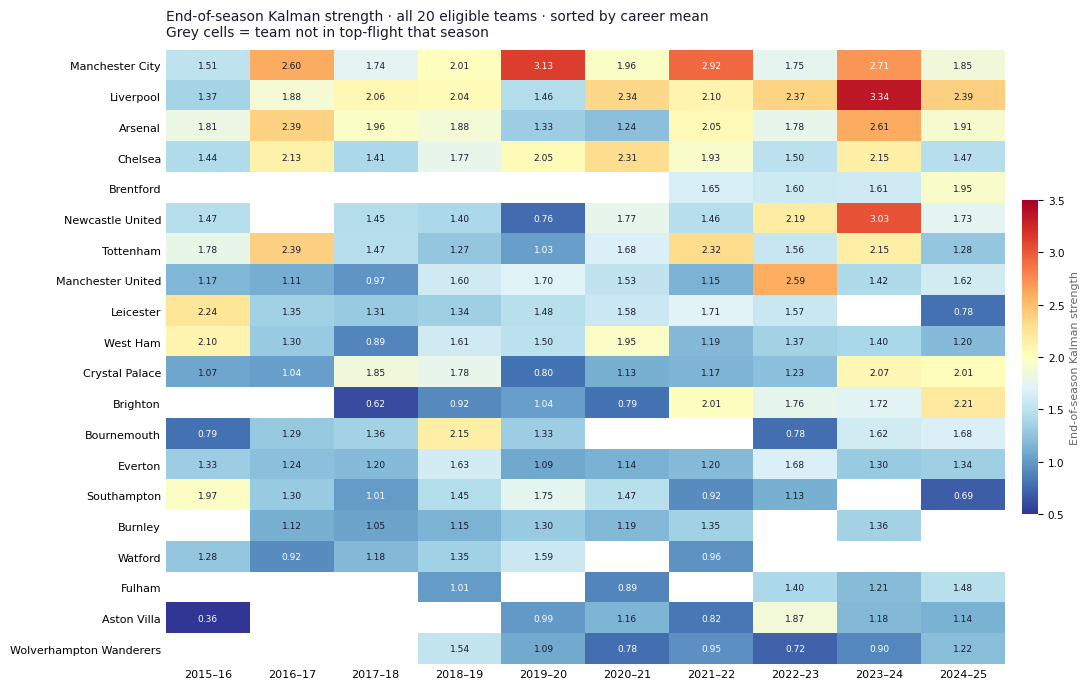

In [9]:
# ─────────────────────────────────────────────────────────────────
# FIG 3 — End-of-season strength heatmap: all teams × all seasons
# ─────────────────────────────────────────────────────────────────

seasons_list = sorted(end_season['season'].unique())

# Pivot to matrix: teams × seasons
matrix_df = (
    end_season
    .pivot(index='team', columns='season', values='kalman_strength')
)

# Sort teams by mean strength (descending); NaN seasons for non-eligible years
matrix_df = matrix_df.loc[
    matrix_df.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(11, 7))

cmap = plt.cm.RdYlBu_r
norm = mcolors.Normalize(vmin=0.5, vmax=3.5)

im = ax.imshow(matrix_df.values, aspect='auto', cmap=cmap, norm=norm)

# Cell value labels
for i in range(matrix_df.shape[0]):
    for j in range(matrix_df.shape[1]):
        val = matrix_df.iloc[i, j]
        if np.isnan(val):
            continue
        # Light text on very dark or very light cells
        normed = (val - 0.5) / 3.0
        txt_col = 'white' if normed > 0.72 or normed < 0.18 else DARK
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=txt_col)

ax.set_xticks(range(len(seasons_list)))
ax.set_xticklabels(
    [f"{s}–{str(s+1)[-2:]}" for s in seasons_list],
    fontsize=8
)
ax.set_yticks(range(len(matrix_df)))
ax.set_yticklabels(matrix_df.index, fontsize=8)
ax.tick_params(length=0)
ax.spines[:].set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.018, pad=0.02)
cbar.ax.tick_params(labelsize=7.5)
cbar.set_label('End-of-season Kalman strength', fontsize=8, color=GREY)
cbar.outline.set_visible(False)

ax.set_title(
    'End-of-season Kalman strength · all 20 eligible teams · sorted by career mean\n'
    'Grey cells = team not in top-flight that season',
    fontsize=10, color=DARK, pad=10, loc='left'
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_fig3_strength_heatmap.png')
plt.show()

### Season Rankings: Four Seasons of Interest

Four seasons expose the gap between the Kalman strength signal and the league table — the core thesis of this notebook.
2015–16 is the most striking: Leicester rank first by Kalman strength, with West Ham second and Southampton third. This is not a quirk of the model — it reflects genuine xG dominance. Ranieri's side created more high-quality chances than any team that season. The league table agreed; the betting markets did not.
2019–20 reveals a well-known divergence: Manchester City led the league in xG strength at 3.12 — a full point clear of Chelsea in second — but Liverpool won the title by 18 points. The model correctly flags this as a difference in finishing efficiency rather than underlying quality, and City's subsequent three-peat was consistent with their latent strength signal.
2022–23 contains a surprise: Manchester United rank first under Ten Hag's debut season. This is less a reflection of their defensive record (which drove the league table) than the model's focus purely on attacking xG. United attacked with more intensity than their mid-table finish suggested.
2024–25 tells a clear story of transition. Liverpool lead comfortably. But the three sides below them — Brighton, Crystal Palace, and Brentford — sit ahead of Arsenal and Manchester City on the strength metric, reflecting a structural shift in how Premier League squads are assembled and coached.

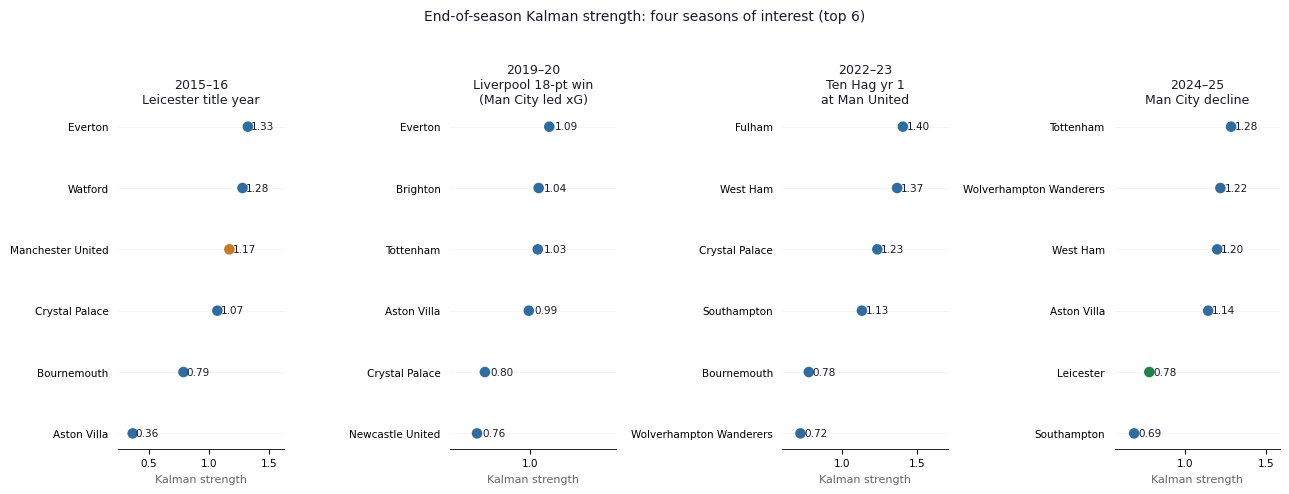

In [10]:
# ─────────────────────────────────────────────────────────────────
# FIG 4 — Season ranking dot plots: 4 annotated seasons
# ─────────────────────────────────────────────────────────────────

season_meta = {
    2015: 'Leicester title year',
    2019: 'Liverpool 18-pt win\n(Man City led xG)',
    2022: 'Ten Hag yr 1\nat Man United',
    2024: 'Man City decline',
}

highlight = {
    'Leicester':        GREEN,
    'Manchester City':  '#6CABDD',
    'Liverpool':        RED,
    'Manchester United': AMBER,
}

fig, axes = plt.subplots(1, 4, figsize=(13, 4.8))

for ax, season in zip(axes, [2015, 2019, 2022, 2024]):
    top6 = (
        end_season[end_season['season'] == season]
        .sort_values('kalman_strength', ascending=True)
        .head(6)
    )
    teams_s  = top6['team'].tolist()
    values   = top6['kalman_strength'].tolist()
    y        = np.arange(len(teams_s))
    colours  = [highlight.get(t, BLUE) for t in teams_s]

    # Faint guide rules
    for yi in y:
        ax.axhline(yi, color='#F5F5F5', lw=0.6, zorder=0)

    ax.scatter(values, y, color=colours, s=58, zorder=3, linewidths=0)

    # Direct value labels
    for val, yi in zip(values, y):
        ax.text(val + 0.025, yi, f'{val:.2f}',
                va='center', fontsize=7.5, color=DARK)

    ax.set_yticks(y)
    ax.set_yticklabels(teams_s, fontsize=8.5)
    ax.set_title(f'{season}–{str(season+1)[-2:]}\n{season_meta[season]}',
                 fontsize=9, color=DARK, pad=6)
    ax.set_xlabel('Kalman strength', fontsize=8, color=GREY)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, labelsize=7.5)
    ax.set_xlim(min(values) - 0.12, max(values) + 0.30)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))

fig.suptitle(
    'End-of-season Kalman strength: four seasons of interest (top 6)',
    fontsize=10, color=DARK, y=1.02
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_fig4_season_rankings.png')
plt.show()

### Noise Parameter Space: Q vs R

This scatter places every team in the two-dimensional noise parameter space. The 
horizontal axis is R (measurement noise: how erratic a single match's xG is), and the 
vertical axis is Q (process noise: how much team strength drifts between seasons).

The Q = R boundary lies entirely above the plot frame — it would only appear at y ≥ 0.37, 
well above the highest Q in the dataset (Newcastle, 0.249). This is the empirical 
confirmation of the model assumption: match-level xG is always noisier than 
season-to-season drift. The dashed line at Q = R/2 provides a reference within the 
visible frame; most teams cluster below it.

Dot size and colour both encode the Q/R ratio, making the most reactive teams 
immediately visible. Newcastle sit in the top-right corner — high R (noisy individual 
matches) and the highest Q of any team (large season-to-season swings in underlying 
strength), reflecting a decade that included ownership change and rapid squad overhaul. 
Brentford sit in the bottom-left with the lowest Q/R ratio, though this partly reflects 
the Q floor applied to teams with few Premier League seasons rather than genuine 
underlying stability.

Manchester City occupy the extreme right on the x-axis — their R of 1.01 is the highest 
in the dataset, meaning individual City matches are the most difficult to predict from 
their latent strength alone. This is partly a mathematical artefact of very high xG 
totals: the absolute variance of a Poisson-like process scales with its mean.


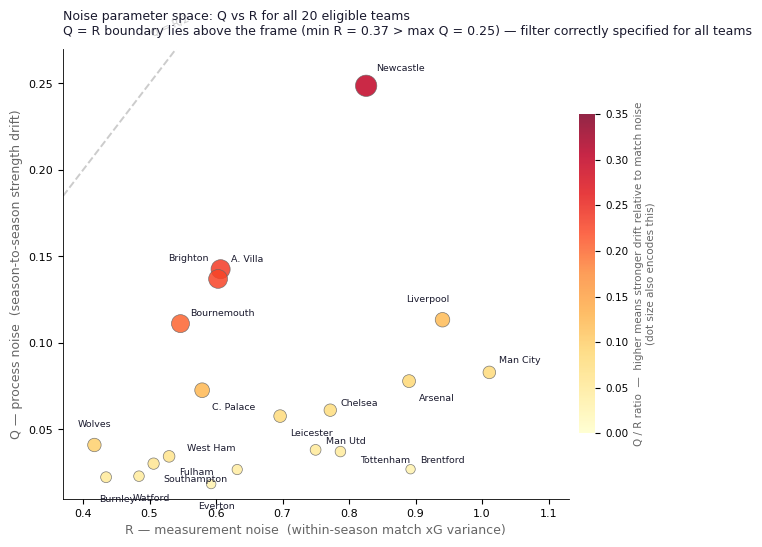

In [32]:
# ─────────────────────────────────────────────────────────────────
# FIG 5 — Noise parameter space: Q vs R scatter
# Note: Q = R boundary (y = x) lies entirely above the plot frame,
# since max(Q) ≈ 0.249 but min(R) = 0.37 — the line would only
# appear at y ≥ 0.37, well above YLIM[1] = 0.270. This is itself
# the finding: all teams are far below misspecification. The diagonal
# is therefore removed and the result stated in the title instead.
# ─────────────────────────────────────────────────────────────────

abbrev = {
    'Wolverhampton Wanderers': 'Wolves',
    'Manchester City':         'Man City',
    'Manchester United':       'Man Utd',
    'Newcastle United':        'Newcastle',
    'Crystal Palace':          'C. Palace',
    'Aston Villa':             'A. Villa',
}

offsets = {
    'Newcastle United':        (+0.015,  +0.010),
    'Aston Villa':             (+0.015,  +0.006),
    'Brighton':                (-0.075,  +0.012),
    'Bournemouth':             (+0.015,  +0.006),
    'Liverpool':               (-0.055,  +0.012),
    'Crystal Palace':          (+0.015,  -0.010),
    'Wolverhampton Wanderers': (-0.025,  +0.012),
    'Arsenal':                 (+0.015,  -0.010),
    'Manchester City':         (+0.015,  +0.007),
    'Leicester':               (+0.015,  -0.010),
    'Chelsea':                 (+0.015,  +0.004),
    'Fulham':                  (+0.015,  -0.009),
    'Southampton':             (+0.015,  -0.009),
    'Manchester United':       (+0.015,  +0.005),
    'Burnley':                 (-0.010,  -0.013),
    'Watford':                 (-0.01,  -0.013),
    'Tottenham':               (+0.03,  -0.005),
    'West Ham':                (-0.075,  +0.012),
    'Everton':                 (-0.020,  -0.013),
    'Brentford':               (+0.015,  +0.005),
}

fig, ax = plt.subplots(figsize=(7, 6))

YLIM = (0.010, 0.270)
XLIM = (0.37,  1.13)

# ── Q = R/2 reference line (only valid reference within the frame) ────────────
# Q = R lies above YLIM entirely, so Q = R/2 is the meaningful upper reference.
# Clip to where y = x/2 falls within both axis limits.
x_half = np.linspace(max(XLIM[0], 2 * YLIM[0]), min(XLIM[1], 2 * YLIM[1]), 200)
ax.plot(x_half, x_half / 2, color=LGREY, lw=1.4, ls='--', zorder=0)
ax.text(x_half[-1] - 0.04, x_half[-1] / 2 + 0.006, 'Q = R/2',
        fontsize=7.5, color=LGREY, rotation=23, va='bottom')

# ── Scatter ───────────────────────────────────────────────────────────────────
sc = ax.scatter(
    noise_df['R'], noise_df['Q'],
    c=noise_df['Q_over_R'], cmap='YlOrRd',
    s=noise_df['Q_over_R'] * 700 + 25,
    alpha=0.85, linewidths=0.5, edgecolors=GREY,
    zorder=3, vmin=0, vmax=0.35
)

# ── Team labels ───────────────────────────────────────────────────────────────
for _, row in noise_df.iterrows():
    dx, dy = offsets.get(row['team'], (0.015, 0.005))
    label  = abbrev.get(row['team'], row['team'])
    ax.text(row['R'] + dx, row['Q'] + dy, label,
            fontsize=6.8, color=DARK, va='center')

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(
    'Q / R ratio  —  higher means stronger drift relative to match noise\n'
    '(dot size also encodes this)',
    fontsize=7.5, color=GREY
)
cbar.ax.tick_params(labelsize=7.5)
cbar.outline.set_visible(False)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

ax.set_xlabel('R — measurement noise  (within-season match xG variance)',
              fontsize=9, color=GREY)
ax.set_ylabel('Q — process noise  (season-to-season strength drift)',
              fontsize=9, color=GREY)
ax.tick_params(labelsize=8)
ax.set_title(
    'Noise parameter space: Q vs R for all 20 eligible teams\n'
    'Q = R boundary lies above the frame (min R = 0.37 > max Q = 0.25) — filter correctly specified for all teams',
    fontsize=9, color=DARK, pad=10, loc='left'
)

fig.subplots_adjust(top=0.87, bottom=0.12, left=0.12, right=0.88)

plt.savefig(FIG_DIR / 'nb03_fig5_Q_vs_R_scatter.png')
plt.show()

Dot size and colour encode the Q/R ratio — teams with a higher ratio have stronger season-to-season drift relative to match-level noise, causing the filter to discount prior estimates and respond more strongly to new results.

| Team | Q | R | Q/R | Note |
|---|---|---|---|---|
| Newcastle | 0.249 | 0.826 | 0.301 | Highest Q/R — most reactive filter |
| Aston Villa | 0.143 | 0.607 | 0.235 | |
| Brighton | 0.137 | 0.603 | 0.227 | |
| Bournemouth | 0.111 | 0.546 | 0.203 | |
| · · · | | | | |
| Southampton | 0.030 | 0.506 | 0.060 | Gradual decline — filter detected early |
| Everton | 0.018 | 0.593 | 0.031 | |
| Brentford | 0.027 | 0.892 | 0.030 | Lowest Q/R — Q floored, interpret with caution |

---
**Q < R for all 20 teams** — the filter is correctly specified. Measurement noise 
(match-to-match xG variance) exceeds process noise (season-to-season drift) in every 
case. The filter appropriately leans on history rather than chasing individual match 
outcomes.

**Newcastle: highest Q/R ratio (0.301)** — the most reactive filter. Their strength 
estimate updates quickly, reflecting large season-to-season swings across a decade that 
included a change of ownership in 2021 and a rapid squad overhaul under PIF investment.

**Brentford: lowest Q/R ratio (0.030)** — the most stable filter, though this partly 
reflects data sparsity. With only a few Premier League seasons available, their process 
noise Q was floored at 0.01 to prevent filter degeneracy. The ratio should be 
interpreted with caution rather than as evidence of genuine underlying stability.

**Season ranking highlights:**
- **2015–16:** Leicester ranked 1st by Kalman strength — consistent with their xG/goals 
  ratio of 1.006. The model confirms genuine performance.
- **2019–20:** Man City ranked 1st by xG strength but Liverpool won by 18 points — the 
  divergence between chance creation and efficiency that the model correctly flags as 
  unsustainable. City won the next 3 titles.
- **2024–25:** Man City dropped to 5th — lowest Kalman strength since 2015–16, 
  consistent with widely observed decline in their attacking output.
- **Southampton:** low Q/R ratio (0.060) reflects the filter's treatment of their 
  strength as slowly changing. This produced wide confidence bounds that tracked gradual 
  institutional decline — the Kalman filter detected the deterioration before the league 
  table confirmed it.

---

## Output Files

| File | Description |
|---|---|
| `pl_kalman_strength.csv` | Match-level Kalman estimates (strength + variance) |
| `kalman_end_season.csv` | End-of-season strength rankings |


## Summary

The Kalman filter provides a stable, causal estimate of team strength that complements 
the O‑U spread model. It:

- identifies long‑run trends and gradual decline (e.g., Southampton's steady 
  deterioration, detected before the league table confirmed it).
- captures rapid structural shifts (e.g., Newcastle's post-takeover squad overhaul, 
  reflected in the highest Q/R ratio in the dataset).
- highlights efficiency anomalies (e.g., Liverpool 2019–20, where xG strength and 
  points diverged sharply).
- provides opponent‑quality conditioning for the trading simulation.

Next, Notebook 04 uses these strength estimates to detect structural breaks via a 
Hidden Markov Model.

In [33]:
print(noise_df.loc[noise_df['Q_over_R'].idxmin()])

team        Brentford
Q            0.027044
R            0.892392
Q_over_R       0.0303
Name: 19, dtype: object


In [34]:
print(noise_df.sort_values('Q_over_R').to_string(index=False))

                   team        Q        R  Q_over_R
              Brentford 0.027044 0.892392    0.0303
                Everton 0.018494 0.592543    0.0312
               West Ham 0.026863 0.631750    0.0425
              Tottenham 0.037249 0.786957    0.0473
                Watford 0.023024 0.484030    0.0476
      Manchester United 0.038231 0.749615    0.0510
                Burnley 0.022431 0.434563    0.0516
            Southampton 0.030271 0.505992    0.0598
                 Fulham 0.034474 0.529295    0.0651
                Chelsea 0.061162 0.771690    0.0793
        Manchester City 0.082988 1.010885    0.0821
              Leicester 0.057742 0.696254    0.0829
                Arsenal 0.077938 0.890164    0.0876
Wolverhampton Wanderers 0.041046 0.416991    0.0984
              Liverpool 0.113406 0.940451    0.1206
         Crystal Palace 0.072680 0.579002    0.1255
            Bournemouth 0.111165 0.546416    0.2034
               Brighton 0.136996 0.602951    0.2272
            